# S&P 500 Momentum Analysis

## Project Objective

This project investigates whether historical market winners continue to outperform over time and whether lower-volatility stocks generate superior risk-adjusted returns.

The analysis uses a representative sample of 30 large-cap S&P 500 companies across technology, financials, healthcare, energy, consumer and industrial sectors.

The dataset was prepared using Python and analysed using SQL.

# Finance Theory

This project is motivated by the weak-form Efficient Market Hypothesis (EMH) and the momentum investing hypothesis.

The weak-form EMH suggests that historical price information is already reflected in current stock prices. If this theory holds, past price performance alone should not consistently predict future returns.

Momentum investing challenges this view by proposing that stocks which have performed well historically may continue to outperform over subsequent periods.

Rather than performing a formal momentum trading backtest, this project investigates whether historical market winners exhibited characteristics consistent with the momentum hypothesis by comparing long-term returns, average daily returns, volatility and risk-adjusted performance across a representative sample of S&P 500 companies.

The findings are used to discuss whether the observed evidence appears consistent with momentum investing and how it relates to the weak-form Efficient Market Hypothesis.

# Loading the Dataset

## Objective

Load the prepared S&P 500 stock dataset into Python to begin the investment analysis.

## Method

The dataset is imported using the Pandas library and stored in a DataFrame named `stocks`. The first five rows are displayed to verify that the dataset has loaded successfully and to inspect its structure before performing any analysis.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

stocks = pd.read_csv("../Data/sp500_stocks_selected.csv")

stocks.head()

,date,open,high,low,close,volume,symbol
0,2000-01-03,0.784870,0.841934,0.761015,0.837724,535796800.0,AAPL
1,2000-01-04,0.810128,0.827901,0.757273,0.767096,512377600.0,AAPL
2,2000-01-05,0.776450,0.827434,0.770837,0.778321,778321600.0,AAPL
3,2000-01-06,0.794224,0.800772,0.710966,0.710966,767972800.0,AAPL
4,2000-01-07,0.722192,0.755870,0.714709,0.744644,460734400.0,AAPL


## Results

The dataset loaded successfully into a Pandas DataFrame.

The output displayed the first five observations containing the following variables:

- `date`
- `open`
- `high`
- `low`
- `close`
- `volume`
- `symbol`

Each row represents the daily trading activity for a single company on a given trading day.

## Interpretation

The dataset has been imported successfully and contains all variables required for the analysis. The initial inspection confirms that the data is correctly structured and ready for preprocessing before calculating investment performance metrics.

# Converting the Date Column

## Objective

Convert the `date` column from a text data type into a datetime format so that Python can correctly recognise dates for time-series analysis.

## Method

The `pd.to_datetime()` function is used to convert every value in the `date` column into a datetime object. The `info()` method is then used to verify the conversion and inspect the overall structure of the DataFrame.

In [2]:
stocks["date"] = pd.to_datetime(stocks["date"])

stocks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187343 entries, 0 to 187342
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    187343 non-null  datetime64[ns]
 1   open    187343 non-null  float64       
 2   high    187343 non-null  float64       
 3   low     187343 non-null  float64       
 4   close   187343 non-null  float64       
 5   volume  187343 non-null  float64       
 6   symbol  187343 non-null  object        
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 10.0+ MB


## Results

The `date` column was successfully converted from an `object` data type to `datetime64[ns]`.

The `stocks` DataFrame contains:

- **187,343 observations (rows)**
- **7 variables (columns)**

The dataset consists of:

| Variable | Data Type |
|----------|-----------|
| date | datetime64[ns] |
| open | float64 |
| high | float64 |
| low | float64 |
| close | float64 |
| volume | float64 |
| symbol | object |

All **187,343** records contain non-null values across every column, indicating that no missing data is present in the imported dataset.

## Interpretation

Successfully converting the `date` column enables Python to recognise dates correctly, allowing chronological operations such as sorting, filtering, grouping by time period and calculating investment performance over time.

The output also confirms that the dataset contains no missing values and that each variable has been assigned an appropriate data type. This provides a reliable foundation for the subsequent financial analysis.

# Calculating Daily Returns

## Objective

Calculate the daily percentage return for each company in the dataset.

Daily returns measure the percentage change in a company's closing share price from one trading day to the next. They form the foundation for measuring investment performance and risk.

## Method

The dataset is first sorted by company (`symbol`) and trading date to ensure observations are in chronological order.

The `pct_change()` function is then applied to each company's closing price series to calculate the daily percentage return. The resulting values are stored in a new column named `daily_return`.

In [3]:
# Sort observations chronologically
stocks = stocks.sort_values(["symbol", "date"])

# Calculate daily percentage returns
stocks["daily_return"] = (
    stocks.groupby("symbol")["close"]
    .pct_change()
)

stocks.head()

,date,open,high,low,close,volume,symbol,daily_return
0,2000-01-03,0.784870,0.841934,0.761015,0.837724,535796800.0,AAPL,NaN
1,2000-01-04,0.810128,0.827901,0.757273,0.767096,512377600.0,AAPL,-0.084310
2,2000-01-05,0.776450,0.827434,0.770837,0.778321,778321600.0,AAPL,0.014633
3,2000-01-06,0.794224,0.800772,0.710966,0.710966,767972800.0,AAPL,-0.086539
4,2000-01-07,0.722192,0.755870,0.714709,0.744644,460734400.0,AAPL,0.047369


## Results

A new variable named `daily_return` was successfully created.

The first observation for each company contains a `NaN` value because there is no previous trading day from which to calculate a percentage change. This is expected behaviour when using the `pct_change()` function.

Subsequent observations contain the daily percentage return based on the change in closing price from the previous trading day.

For example, Apple's closing price decreased by **8.43%** between 3 January 2000 and 4 January 2000, followed by a **1.46%** increase on the next trading day.

## Interpretation

Daily returns provide a standardised measure of investment performance that allows comparisons across companies regardless of their share price.

Rather than comparing absolute price movements, daily returns express gains and losses as percentages, making them suitable for calculating investment risk, average returns and other financial performance metrics.

This new variable forms the foundation for the remaining analysis, including volatility, risk-adjusted performance and momentum investing.

# Average Daily Return by Company

## Objective

Calculate the average daily return for each company in the dataset.

Average daily return provides a measure of the typical percentage gain or loss achieved on a trading day. Comparing these values allows us to identify which companies delivered the strongest average daily performance over the sample period.

## Method

The `daily_return` column is grouped by company (`symbol`) and the mean daily return is calculated for each stock.

The results are converted into percentages and ranked from highest to lowest average daily return.

In [4]:
average_returns = (
    stocks.groupby("symbol")["daily_return"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
    .round(4)
)

average_returns

symbol
NVDA     0.1847
AAPL     0.1185
MA       0.1148
GOOGL    0.1086
META     0.1076
AMZN     0.1056
CRM      0.0989
V        0.0872
CAT      0.0867
UNH      0.0860
ABBV     0.0852
ADBE     0.0726
MS       0.0704
GS       0.0688
JPM      0.0669
COST     0.0665
COP      0.0624
ORCL     0.0605
BAC      0.0596
RTX      0.0570
NKE      0.0539
MSFT     0.0531
CVX      0.0513
MCD      0.0487
XOM      0.0452
WMT      0.0427
JNJ      0.0419
GE       0.0370
MRK      0.0370
PFE      0.0245
Name: daily_return, dtype: float64

## Results

The average daily return was successfully calculated for all 30 companies in the dataset.

The highest average daily returns were:

| Rank | Company | Average Daily Return |
|------|---------|---------------------:|
| 1 | NVDA | 0.1847% |
| 2 | AAPL | 0.1185% |
| 3 | MA | 0.1148% |
| 4 | GOOGL | 0.1086% |
| 5 | META | 0.1076% |

The lowest average daily return was recorded by **PFE** at **0.0245%** per trading day.

## Interpretation

Average daily return provides a standardised measure of a company's typical daily investment performance.

Technology companies dominate the highest rankings, with NVDA, AAPL, GOOGL and META all producing exceptionally strong average daily gains over the sample period.

Although these results indicate superior average performance, higher returns do not necessarily imply better investments. The next stage of the analysis will examine volatility to determine whether these higher returns were achieved by accepting greater investment risk.

# Measuring Investment Risk (Volatility)

## Objective

Measure the level of investment risk associated with each company.

In finance, volatility is commonly measured using the standard deviation of daily returns. Companies with larger fluctuations in daily returns are considered more volatile and therefore generally carry greater investment risk.

## Method

The standard deviation of the `daily_return` variable is calculated for each company.

The results are converted into percentages and ranked from the highest volatility (highest risk) to the lowest volatility (lowest risk).

In [5]:
volatility = (
    stocks.groupby("symbol")["daily_return"]
    .std()
    .mul(100)
    .sort_values(ascending=False)
    .round(4)
)

volatility

symbol
NVDA     3.7005
AMZN     3.0626
MS       2.9398
BAC      2.7074
ADBE     2.6514
CRM      2.6237
META     2.5041
ORCL     2.4746
AAPL     2.4133
JPM      2.3183
GS       2.2507
GE       2.0932
COP      2.0918
MA       2.0357
CAT      2.0275
UNH      2.0115
NKE      1.9744
GOOGL    1.9329
MSFT     1.8939
V        1.7905
RTX      1.7391
CVX      1.7260
COST     1.6910
ABBV     1.6601
MRK      1.6591
XOM      1.6562
PFE      1.5827
WMT      1.4787
MCD      1.4268
JNJ      1.2041
Name: daily_return, dtype: float64

## Results

The standard deviation of daily returns was successfully calculated for all 30 companies.

The highest levels of daily volatility were observed in:

| Rank | Company | Daily Volatility |
|------|---------|-----------------:|
| 1 | NVDA | 3.7005% |
| 2 | AMZN | 3.0626% |
| 3 | MS | 2.9398% |
| 4 | BAC | 2.7074% |
| 5 | ADBE | 2.6514% |

The lowest daily volatility was recorded by **JNJ** at **1.2041%**.

## Interpretation

Daily volatility measures the variability of a company's daily returns and is widely used as a proxy for investment risk.

The results indicate that companies producing the highest long-term returns, particularly NVDA, also experienced substantially larger day-to-day price fluctuations.

Conversely, companies such as JNJ, MCD and WMT exhibited lower daily volatility, suggesting more stable share price behaviour over the sample period.

These findings suggest a potential relationship between higher returns and higher risk, which will be examined more closely in the next stage of the analysis.

# Combining Return and Risk Metrics

## Objective

Combine the average daily return and daily volatility calculations into a single DataFrame.

Bringing these metrics together allows each company's investment performance and risk to be analysed side by side. This creates the foundation for comparing return against risk and calculating additional performance measures such as the Sharpe Ratio.

## Method

The average daily return and daily volatility results are first converted into separate DataFrames using the `reset_index()` method.

The two DataFrames are then combined using a left join (`pd.merge()`), matching each company by its stock ticker (`symbol`).

Finally, the columns are renamed to provide clear and descriptive variable names.

In [6]:
average_returns_df = average_returns.reset_index()

volatility_df = volatility.reset_index()

average_returns_df.head()

,symbol,daily_return
0,NVDA,0.1847
1,AAPL,0.1185
2,MA,0.1148
3,GOOGL,0.1086
4,META,0.1076


In [7]:
performance_summary = pd.merge(
    average_returns_df,
    volatility_df,
    on="symbol",
    how="left"
)

performance_summary.columns = [
    "symbol",
    "average_daily_return",
    "daily_volatility"
]

performance_summary

,symbol,average_daily_return,daily_volatility
0,NVDA,0.1847,3.7005
1,AAPL,0.1185,2.4133
2,MA,0.1148,2.0357
3,GOOGL,0.1086,1.9329
4,META,0.1076,2.5041
5,AMZN,0.1056,3.0626
6,CRM,0.0989,2.6237
7,V,0.0872,1.7905
8,CAT,0.0867,2.0275
9,UNH,0.0860,2.0115


## Results

The average daily return and daily volatility metrics were successfully combined into a single DataFrame using a left join on the `symbol` column.

The resulting dataset contains one row for each of the 30 companies, with the following variables:

- `symbol`
- `average_daily_return`
- `daily_volatility`

This provides a consolidated view of each company's average investment performance and associated level of risk.

## Interpretation

Combining these metrics allows investment performance and risk to be analysed simultaneously rather than in isolation.

The merged DataFrame highlights several interesting relationships. For example, **NVDA** produced the highest average daily return (0.1847%) but also exhibited the highest daily volatility (3.7005%). In contrast, companies such as **JNJ** and **WMT** generated lower average daily returns while experiencing substantially lower levels of volatility.

This consolidated dataset forms the foundation for the remaining analysis, including the risk-versus-return comparison and the calculation of the Sharpe Ratio.

# Risk versus Return Analysis

## Objective

Visualise the relationship between average daily return and daily volatility for each company.

Investment theory generally suggests that achieving higher returns requires accepting higher levels of risk. A scatter plot allows this relationship to be examined by comparing each company's average daily return against its daily volatility.

## Method

A scatter plot is created using Matplotlib.

Each point represents one company, where:

- The x-axis shows daily volatility (risk).
- The y-axis shows average daily return (reward).

Each point is labelled with its stock ticker to make individual companies easy to identify.

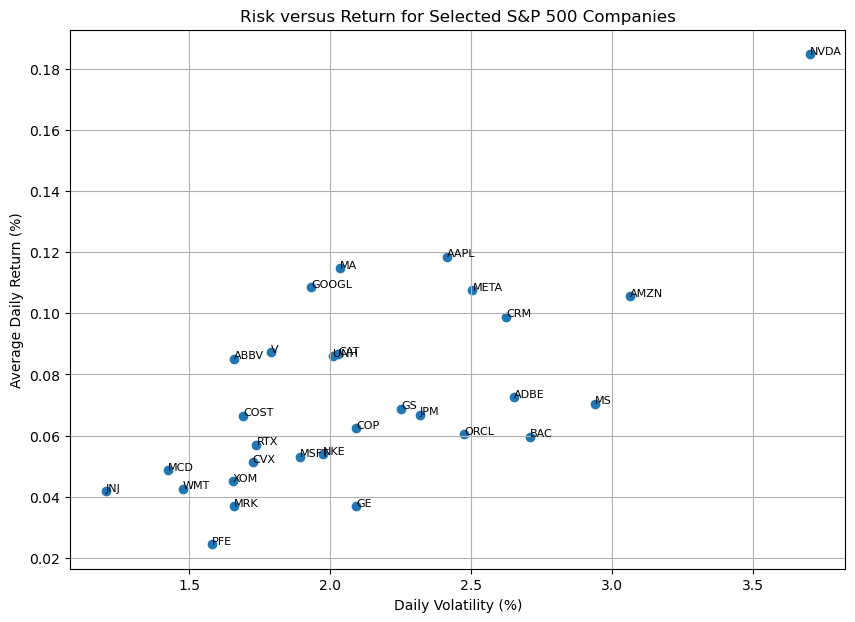

In [8]:
plt.figure(figsize=(10, 7))

plt.scatter(
    performance_summary["daily_volatility"],
    performance_summary["average_daily_return"]
)

for i, row in performance_summary.iterrows():
    plt.text(
        row["daily_volatility"],
        row["average_daily_return"],
        row["symbol"],
        fontsize=8
    )

plt.title("Risk versus Return for Selected S&P 500 Companies")
plt.xlabel("Daily Volatility (%)")
plt.ylabel("Average Daily Return (%)")
plt.grid(True)

# Save image
plt.savefig("../Images/risk_vs_return.png", dpi=300, bbox_inches="tight")

plt.show()

## Results

The scatter plot compares the average daily return and daily volatility for each of the 30 companies.

Several clear patterns emerge:

- NVDA stands out as the highest-return and highest-volatility stock in the dataset.
- Companies such as AAPL, MA and GOOGL achieved relatively high average daily returns while maintaining lower volatility than NVDA.
- Defensive companies including JNJ, WMT and PFE occupy the lower-left region of the chart, reflecting lower returns and lower investment risk.

## Interpretation

The scatter plot suggests a positive relationship between investment risk and return. Companies that generated higher average daily returns generally experienced greater day-to-day price fluctuations.

However, the relationship is not perfectly linear. Some companies delivered stronger returns without a proportional increase in volatility, indicating that investors were rewarded more efficiently for the level of risk taken.

This observation motivates the next stage of the analysis, where the Sharpe Ratio is calculated to evaluate which companies generated the highest return per unit of risk.

# Sharpe Ratio Analysis

## Objective

Evaluate the risk-adjusted performance of each company using the Sharpe Ratio.

While average daily return measures investment performance and volatility measures investment risk, the Sharpe Ratio combines both metrics into a single measure. It estimates how much return was generated for each unit of risk taken.

## Method

The Sharpe Ratio is calculated by dividing the average daily return by the standard deviation of daily returns.

For simplicity, this analysis assumes a daily risk-free rate of zero, allowing direct comparison of each company's risk-adjusted performance.

The companies are then ranked from the highest Sharpe Ratio to the lowest.

In [9]:
performance_summary["sharpe_ratio"] = (
    performance_summary["average_daily_return"]
    / performance_summary["daily_volatility"]
)

performance_summary = performance_summary.sort_values(
    by="sharpe_ratio",
    ascending=False
)

performance_summary.round(4)

,symbol,average_daily_return,daily_volatility,sharpe_ratio
2,MA,0.1148,2.0357,0.0564
3,GOOGL,0.1086,1.9329,0.0562
10,ABBV,0.0852,1.6601,0.0513
0,NVDA,0.1847,3.7005,0.0499
1,AAPL,0.1185,2.4133,0.0491
7,V,0.0872,1.7905,0.0487
4,META,0.1076,2.5041,0.0430
8,CAT,0.0867,2.0275,0.0428
9,UNH,0.0860,2.0115,0.0428
15,COST,0.0665,1.6910,0.0393


## Results

The Sharpe Ratio was calculated for all 30 companies by dividing average daily return by daily volatility.

The highest risk-adjusted performers were:

| Rank | Company | Sharpe Ratio |
|------|---------|-------------:|
| 1 | MA | 0.0564 |
| 2 | GOOGL | 0.0562 |
| 3 | ABBV | 0.0513 |
| 4 | NVDA | 0.0499 |
| 5 | AAPL | 0.0491 |

The lowest Sharpe Ratio was recorded by **PFE** at **0.0155**.

## Interpretation

The Sharpe Ratio evaluates investment performance relative to the amount of risk taken.

Although NVDA generated the highest average daily return, it ranked fourth in terms of risk-adjusted performance because its exceptionally high returns were accompanied by the highest level of volatility.

Conversely, companies such as MA and GOOGL achieved slightly lower average daily returns while exposing investors to substantially lower levels of daily risk, resulting in superior risk-adjusted performance.

These findings demonstrate that the highest-return investment is not necessarily the most efficient investment once risk is considered.

# Momentum Investing Analysis

## Objective

Investigate whether companies that generated the highest long-term returns also produced the strongest average daily performance.

Momentum investing suggests that assets with strong historical performance may continue to outperform over time. This section compares cumulative investment returns with the average daily returns calculated earlier in the analysis.

## Method

The first and last closing price for each company are identified using the original stock dataset.

The cumulative percentage return is then calculated for each company before being merged with the previously created performance summary containing average daily return, volatility and Sharpe Ratio.

This creates a single dataset containing all key investment performance metrics.

In [10]:
total_returns = (
    stocks.groupby("symbol")
    .agg(
        first_close=("close", "first"),
        last_close=("close", "last")
    )
)

total_returns["total_return_pct"] = (
    (total_returns["last_close"] - total_returns["first_close"])
    / total_returns["first_close"]
) * 100

total_returns = (
    total_returns[["total_return_pct"]]
    .reset_index()
)

total_returns.head()

,symbol,total_return_pct
0,AAPL,35354.387673
1,ABBV,1018.667775
2,ADBE,1097.566654
3,AMZN,5109.286563
4,BAC,366.707206


In [11]:
performance_summary = pd.merge(
    performance_summary,
    total_returns,
    on="symbol",
    how="left"
)

performance_summary.head()

,symbol,average_daily_return,daily_volatility,sharpe_ratio,total_return_pct
0,MA,0.1148,2.0357,0.056393,11517.999477
1,GOOGL,0.1086,1.9329,0.056185,13949.350009
2,ABBV,0.0852,1.6601,0.051322,1018.667775
3,NVDA,0.1847,3.7005,0.049912,233534.178758
4,AAPL,0.1185,2.4133,0.049103,35354.387673


In [12]:
performance_summary = performance_summary[
    [
        "symbol",
        "total_return_pct",
        "average_daily_return",
        "daily_volatility",
        "sharpe_ratio"
    ]
].sort_values(
    by="total_return_pct",
    ascending=False
).reset_index(drop=True)

performance_summary

,symbol,total_return_pct,average_daily_return,daily_volatility,sharpe_ratio
0,NVDA,233534.178758,0.1847,3.7005,0.049912
1,AAPL,35354.387673,0.1185,2.4133,0.049103
2,GOOGL,13949.350009,0.1086,1.9329,0.056185
3,MA,11517.999477,0.1148,2.0357,0.056393
4,CAT,8064.615308,0.0867,2.0275,0.042762
5,UNH,7811.375355,0.0860,2.0115,0.042754
6,AMZN,5109.286563,0.1056,3.0626,0.034481
7,CRM,3451.561590,0.0989,2.6237,0.037695
8,COST,3109.041445,0.0665,1.6910,0.039326
9,V,2530.440206,0.0872,1.7905,0.048701


## Results

The total investment return for each company was calculated directly from the original stock price data and combined with the previously calculated performance metrics.

The final summary table contains one record for each of the 30 companies and includes the following measures:

- Total investment return (%)
- Average daily return (%)
- Daily volatility (%)
- Sharpe Ratio

The results show that **NVDA** generated the highest total investment return over the sample period. It also recorded the highest average daily return, although it experienced the greatest daily volatility.

In contrast, **MA** achieved the highest Sharpe Ratio, indicating the strongest risk-adjusted performance, while **JNJ** exhibited the lowest daily volatility, reflecting comparatively stable price movements.

## Interpretation

Bringing all investment metrics together into a single DataFrame provides a comprehensive overview of each company's historical performance and investment characteristics.

The results demonstrate that the companies producing the greatest long-term returns were not always those delivering the best risk-adjusted performance. While NVDA generated exceptional wealth over the sample period, its returns were accompanied by considerably higher volatility than many other companies.

Conversely, companies such as MA and GOOGL achieved strong returns while maintaining comparatively lower levels of risk, resulting in superior Sharpe Ratios.

This consolidated summary forms the basis for evaluating the momentum investing hypothesis and assessing whether historical market winners consistently exhibited superior investment performance throughout the sample period.

# Historical Investment Performance

## Objective

Visualise the total investment return achieved by each company over the sample period.

Ranking companies by cumulative return highlights the strongest historical performers and provides a clear foundation for evaluating whether these companies also exhibited characteristics consistent with momentum investing.

## Method

A horizontal bar chart is created using the cumulative percentage return calculated for each company.

The companies are ordered from the highest total return to the lowest to enable direct comparison of long-term investment performance.

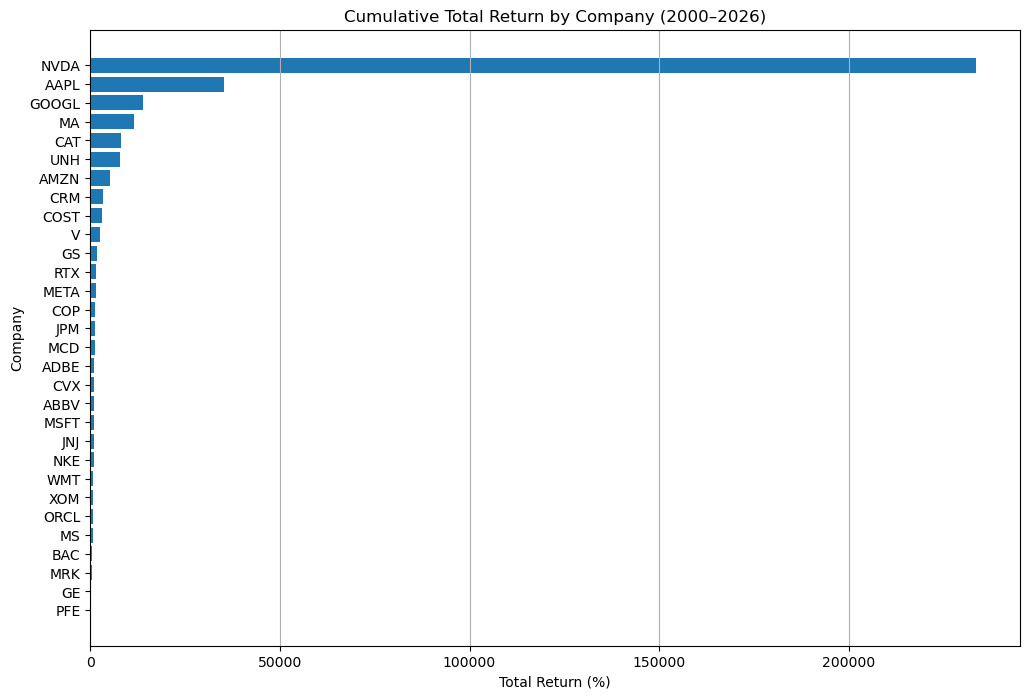

In [13]:
plt.figure(figsize=(12,8))

performance_summary = performance_summary.sort_values(
    by="total_return_pct",
    ascending=True
)

plt.barh(
    performance_summary["symbol"],
    performance_summary["total_return_pct"]
)

plt.title("Cumulative Total Return by Company (2000–2026)")
plt.xlabel("Total Return (%)")
plt.ylabel("Company")
plt.grid(axis="x")

plt.savefig("../Images/total_returns.png", dpi=300, bbox_inches="tight")

plt.show()

## Results

The horizontal bar chart ranks all 30 companies according to their cumulative investment return over the sample period.

Several companies substantially outperformed the remainder of the sample. NVDA generated the highest cumulative return by a considerable margin, followed by AAPL, GOOGL and MA.

The distribution of returns is highly skewed, with a small number of companies accounting for exceptionally large long-term gains while the majority of companies produced more moderate cumulative returns.

## Interpretation

The results demonstrate that long-term investment performance varied considerably across the selected S&P 500 companies.

Technology companies dominate the upper end of the rankings, reflecting the significant growth of the technology sector over the past two decades. In particular, NVDA produced an exceptionally large cumulative return that greatly exceeded every other company included in the analysis.

These findings indicate that historical market winners generated substantially greater long-term returns than the remainder of the sample. However, earlier analyses showed that these exceptional returns were often accompanied by higher levels of volatility, suggesting that superior performance generally required investors to accept greater investment risk.

# Discussion

The analysis identified substantial differences in investment performance across the selected S&P 500 companies between 2000 and 2026.

NVDA generated the highest cumulative return and the highest average daily return, demonstrating exceptional long-term growth. However, it also exhibited the highest daily volatility, indicating that these returns were achieved alongside considerably higher investment risk.

The Sharpe Ratio analysis revealed that MA achieved the strongest risk-adjusted performance despite not producing the highest cumulative return. This demonstrates that the highest-return investment was not necessarily the most efficient once risk was taken into account.

The risk-versus-return analysis suggested a positive relationship between return and volatility. Companies delivering higher returns generally experienced greater day-to-day price fluctuations, supporting the widely accepted principle that higher returns are often associated with higher investment risk.

Technology companies occupied many of the highest-ranking positions for cumulative return, reflecting the significant expansion of the technology sector throughout the sample period.

# Momentum Investing

The analysis found that several historical market winners also achieved exceptionally strong long-term investment performance throughout the sample period. Companies including **NVDA**, **AAPL**, **GOOGL** and **MA** consistently ranked among the strongest performers across multiple investment measures, including cumulative return, average daily return and, in some cases, risk-adjusted performance.

These findings are broadly consistent with characteristics associated with the momentum investing hypothesis. However, this project does not implement a formal momentum trading strategy using rolling formation and holding periods. Consequently, it cannot determine whether momentum investing would have consistently generated abnormal returns or whether historical winners would have continued to outperform in future investment periods.

An important observation is that many of the highest-performing companies belong to the technology sector. The exceptional long-term growth of technology businesses over the sample period may have contributed significantly to the strong returns observed for companies such as **NVDA**, **AAPL** and **GOOGL**. As a result, some of the apparent evidence supporting momentum investing may also reflect sector-specific growth rather than momentum effects alone.

Overall, the results should be interpreted as exploratory evidence that is broadly consistent with the momentum investing hypothesis rather than definitive proof of its existence. Future research could strengthen the analysis by examining a larger and more diversified sample of companies, controlling for sector effects and implementing a formal momentum trading strategy using rolling formation and holding periods.

# Efficient Market Hypothesis

The results provide some evidence that appears inconsistent with the strict interpretation of the weak-form Efficient Market Hypothesis.

Several companies substantially outperformed the broader sample over an extended period while continuing to exhibit strong average returns.

However, because this study does not evaluate a repeatable trading strategy or measure statistical significance, it cannot reject the weak-form Efficient Market Hypothesis.

Instead, the findings demonstrate that historical performance differed considerably between companies and highlight patterns worthy of further investigation.

# Limitations

Several limitations should be considered when interpreting these findings.

- The analysis includes a representative sample of 30 S&P 500 companies rather than the full index.
- Dividend payments and transaction costs were not included in return calculations.
- The project examines historical price performance only and does not consider macroeconomic or company-specific events.
- A formal momentum strategy using rolling formation and holding periods was not implemented.
- Statistical hypothesis testing was beyond the scope of this exploratory analysis.

# Conclusion

This project successfully combined SQL and Python to analyse more than 187,000 daily stock observations covering 30 large-cap S&P 500 companies between 2000 and 2026.

The analysis demonstrated substantial differences in long-term investment performance across the selected companies. NVDA produced the highest cumulative return and the highest average daily return but also exhibited the greatest daily volatility, highlighting the trade-off between investment return and risk.

Risk-adjusted performance showed that the highest-return investments were not always the most efficient once volatility was considered. Companies such as **MA** and **GOOGL** achieved the strongest Sharpe Ratios, demonstrating that investors were rewarded more efficiently for the level of risk accepted.

Overall, the findings are broadly consistent with characteristics associated with the momentum investing hypothesis, as several historical market winners also ranked among the strongest performers across multiple investment measures. However, many of the highest-performing companies, including **NVDA**, **AAPL** and **GOOGL**, belong to the technology sector. The exceptional long-term growth of this sector may have contributed significantly to the observed results, meaning that sector-specific trends, rather than momentum effects alone, may partially explain the strong historical performance.

Consequently, this project should be interpreted as an exploratory investigation rather than a formal test of the momentum hypothesis or the weak-form Efficient Market Hypothesis. Future research could extend the analysis by examining a larger sample of companies, controlling for sector effects and implementing a formal momentum trading strategy using rolling formation and holding periods.